# Cheapest-Alternative Model of the Levantine Neolithic Transition

**Walkthrough notebook.** Run all cells to reproduce the results in
the README.

The model formalizes one hypothesis:

> Cultivation emerges when foragers who have become dependent on
> wild cereals find the cereals disappearing. The cheapest
> alternative to migrating or starving is to cultivate.

A single behavioural rule - choose the cheapest available strategy -
is applied to two strategies (forage, cultivate). No exogenous
transition event is inserted.

## 1. Setup

In [ ]:
%matplotlib inline
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

if 'google.colab' in sys.modules:
    _CLONE_DIR = Path('/content/Neolithic-Transition-model-')
    if not _CLONE_DIR.exists():
        !git clone https://github.com/logikarlo/Neolithic-Transition-model-.git {_CLONE_DIR}
    _REPO_ROOT = _CLONE_DIR
    os.chdir(_REPO_ROOT)
else:
    _here = Path.cwd().resolve()
    _REPO_ROOT = _here
    for _ in range(4):
        if (_REPO_ROOT / "models").exists():
            break
        _REPO_ROOT = _REPO_ROOT.parent

sys.path.insert(0, str(_REPO_ROOT / "models"))

_DATA_DIR = _REPO_ROOT / "data"
_SPD_DIR  = _REPO_ROOT / "xronos SPDs"
_FIG_DIR  = _REPO_ROOT / "figures"

from latest_levant_model import (
    Model, T_START, T_END, DOMESTICATION_START_BP,
    non_shattering_fraction, farming_cost_ratio,
)
from levant_null import fit_null_v2

plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 100
Path("figures").mkdir(exist_ok=True)

print("Repo root:", _REPO_ROOT)
print("Models:   ", _REPO_ROOT / "models")
print("Data:     ", _DATA_DIR)
print("SPDs:     ", _SPD_DIR)

Repo root: C:\Users\Tar Carlion\Documents\python\satisficing-models\forager-farmer-transition
Models:    C:\Users\Tar Carlion\Documents\python\satisficing-models\forager-farmer-transition\models
Data:      C:\Users\Tar Carlion\Documents\python\satisficing-models\forager-farmer-transition\data
SPDs:      C:\Users\Tar Carlion\Documents\python\satisficing-models\forager-farmer-transition\xronos SPDs


## 2. Climate records

Two Soreq Cave d18O records:

- **Bar-Matthews 2003**: Younger Dryas as a drying event.
- **Orland 2012**: Younger Dryas as a cooling event without a
  strong precipitation anomaly.

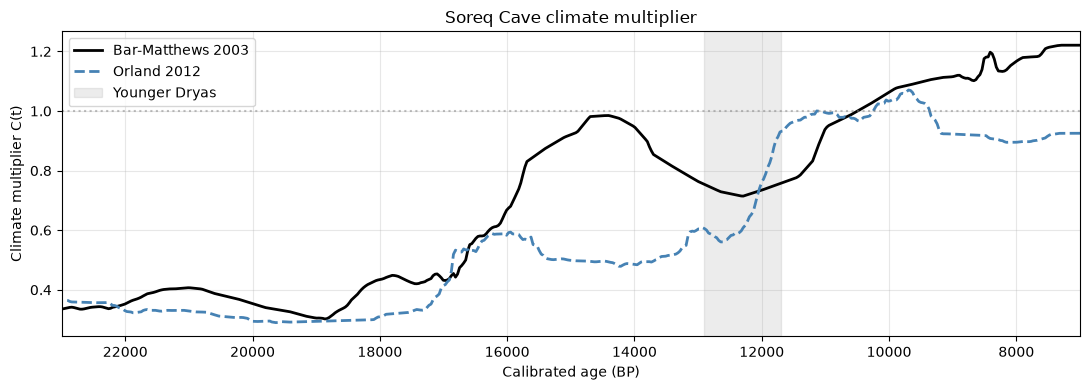

In [3]:
from latest_levant_model import (
    load_climate, T_START, T_END, DOMESTICATION_START_BP,
)

climate_2003 = load_climate(_DATA_DIR / "levant_climate.csv")
climate_2012 = load_climate(_DATA_DIR / "levant_climate2.csv")

t_plot = np.linspace(T_END, T_START, 500)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_plot, [climate_2003(t) for t in t_plot],
        color="black", lw=2, label="Bar-Matthews 2003")
ax.plot(t_plot, [climate_2012(t) for t in t_plot],
        color="steelblue", lw=2, linestyle="--",
        label="Orland 2012")
ax.axhline(1.0, color="grey", ls=":", alpha=0.5)
ax.axvspan(11700, 12900, color="grey", alpha=0.15,
           label="Younger Dryas")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Climate multiplier C(t)")
ax.set_title("Soreq Cave climate multiplier")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 3. Domestication curve and cost ratio

P(t) is the non-shattering fraction. T(t) is a linear map of P(t),
anchored to Bowles (2011): T = 1.5 for wild cultivation, T = 1.0
for fully domesticated cereals.

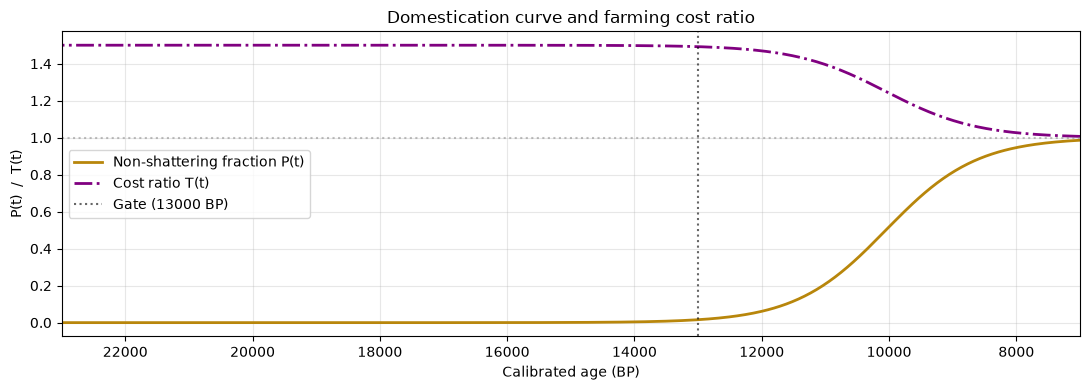

In [4]:
from latest_levant_model import (
    load_climate, T_START, T_END, DOMESTICATION_START_BP, non_shattering_fraction, farming_cost_ratio
)

t_plot = np.linspace(T_END, T_START, 500)
P_plot = [non_shattering_fraction(t) for t in t_plot]
T_plot = [farming_cost_ratio(t) for t in t_plot]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_plot, P_plot, color="darkgoldenrod", lw=2,
        label="Non-shattering fraction P(t)")
ax.plot(t_plot, T_plot, color="purple", lw=2, linestyle="-.",
        label="Cost ratio T(t)")
ax.axhline(1.0, color="grey", ls=":", alpha=0.5)
ax.axvline(DOMESTICATION_START_BP, color="black", ls=":",
           alpha=0.6, label=f"Gate ({DOMESTICATION_START_BP:.0f} BP)")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("P(t)  /  T(t)")
ax.set_title("Domestication curve and farming cost ratio")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 4. Grid model — Bar-Matthews 2003

Expected: forager MSE 0.0273, farmer MSE 0.0087, total 0.0360,
first conversion at 12,975 BP.

`SOIL_DEGR` is the only calibrated free parameter. Value 0.0004
is the MSE minimum under the 2003 record.

In [5]:
from latest_levant_model import (Model,
    load_climate, T_START, T_END, DOMESTICATION_START_BP,
)

def mse_against_empirical(h, emp):
    t = np.array(h["t"])
    F = np.array(h["F"])
    A = np.array(h["A"])
    Fn = F / max(F.max(), 1e-9)
    An = A / max(A.max(), 1e-9)
    elm = emp["forager_raw"] / emp["forager_raw"].max()
    efm = emp["farmer_raw"] / emp["farmer_raw"].max()
    ex = emp["x"]
    Fn_i = np.interp(ex, t[::-1], Fn[::-1])
    An_i = np.interp(ex, t[::-1], An[::-1])
    mse_f = float(np.mean((Fn_i - elm) ** 2))
    mse_a = float(np.mean((An_i - efm) ** 2))
    return mse_f, mse_a


def load_empirical():
    f = np.load(_SPD_DIR / "levant_forager_spd.npz")
    a = np.load(_SPD_DIR / "levant_farmer_spd.npz")
    return {
        "x": f["age"],
        "forager_raw": f["raw"] if "raw" in f.files else f["median"],
        "farmer_raw": a["raw"] if "raw" in a.files else a["median"],
    }


emp = load_empirical()

m_2003 = Model(seed=42, climate_path=_DATA_DIR /"levant_climate.csv")
h_2003 = m_2003.run(verbose=True)

t_2003 = np.array(h_2003["t"])
F_2003 = np.array(h_2003["F"])
A_2003 = np.array(h_2003["A"])
H_2003 = np.array(h_2003["H_mean"])
d_2003 = np.array(h_2003["d_mean"])
P_2003 = np.array(h_2003["P_dom"])
T_2003 = np.array(h_2003["T_ratio"])
share_2003 = np.array(h_2003["farmer_share"])
conv_in_2003 = np.array(h_2003["conv_in_situ"])
conv_cul_2003 = np.array(h_2003["conv_cultural"])
c_for_2003 = np.array(h_2003["c_for_mean"])
c_farm_2003 = np.array(h_2003["c_farm_mean"])
conv_cells_2003 = np.array(h_2003["conv"])

mse_f, mse_a = mse_against_empirical(h_2003, emp)
print(f"Forager MSE: {mse_f:.4f}")
print(f"Farmer MSE:  {mse_a:.4f}")
print(f"Total MSE:   {mse_f + mse_a:.4f}")
print(f"First conversion: {m_2003.first_conversion_bp:.0f} BP")

t=  23000  F=    350.3  A=      0.0  share=0.000
t=  13000  F=  50988.9  A=      0.0  share=0.000
Forager MSE: 0.0273
Farmer MSE:  0.0087
Total MSE:   0.0360
First conversion: 12975 BP


## 5. Grid model — Orland 2012

Expected: forager MSE 0.0242, farmer MSE 0.0089, total 0.0331,
first conversion at 12,975 BP.

In [6]:
from latest_levant_model import (Model,
    load_climate, T_START, T_END, DOMESTICATION_START_BP,
)

def mse_against_empirical(h, emp):
    t = np.array(h["t"])
    F = np.array(h["F"])
    A = np.array(h["A"])
    Fn = F / max(F.max(), 1e-9)
    An = A / max(A.max(), 1e-9)
    elm = emp["forager_raw"] / emp["forager_raw"].max()
    efm = emp["farmer_raw"] / emp["farmer_raw"].max()
    ex = emp["x"]
    Fn_i = np.interp(ex, t[::-1], Fn[::-1])
    An_i = np.interp(ex, t[::-1], An[::-1])
    mse_f = float(np.mean((Fn_i - elm) ** 2))
    mse_a = float(np.mean((An_i - efm) ** 2))
    return mse_f, mse_a


def load_empirical():
    f = np.load(_SPD_DIR / "levant_forager_spd.npz")
    a = np.load(_SPD_DIR / "levant_farmer_spd.npz")
    return {
        "x": f["age"],
        "forager_raw": f["raw"] if "raw" in f.files else f["median"],
        "farmer_raw": a["raw"] if "raw" in a.files else a["median"],
    }


emp = load_empirical()

m_2012 = Model(seed=42, climate_path=_DATA_DIR /"levant_climate2.csv")
h_2012 = m_2012.run(verbose=True)

t_2012 = np.array(h_2012["t"])
F_2012 = np.array(h_2012["F"])
A_2012 = np.array(h_2012["A"])
share_2012 = np.array(h_2012["farmer_share"])

mse_f, mse_a = mse_against_empirical(h_2012, emp)
print(f"Forager MSE: {mse_f:.4f}")
print(f"Farmer MSE:  {mse_a:.4f}")
print(f"Total MSE:   {mse_f + mse_a:.4f}")
print(f"First conversion: {m_2012.first_conversion_bp:.0f} BP")

t=  23000  F=    452.3  A=      0.0  share=0.000
t=  13000  F=  36016.9  A=      0.0  share=0.000
Forager MSE: 0.0242
Farmer MSE:  0.0089
Total MSE:   0.0331
First conversion: 12975 BP


## 6. Diagnostic panels — Bar-Matthews 2003

Six panels: empirical, model populations, habitat and dependence,
climate/domestication/cost, model vs empirical, farmer share.

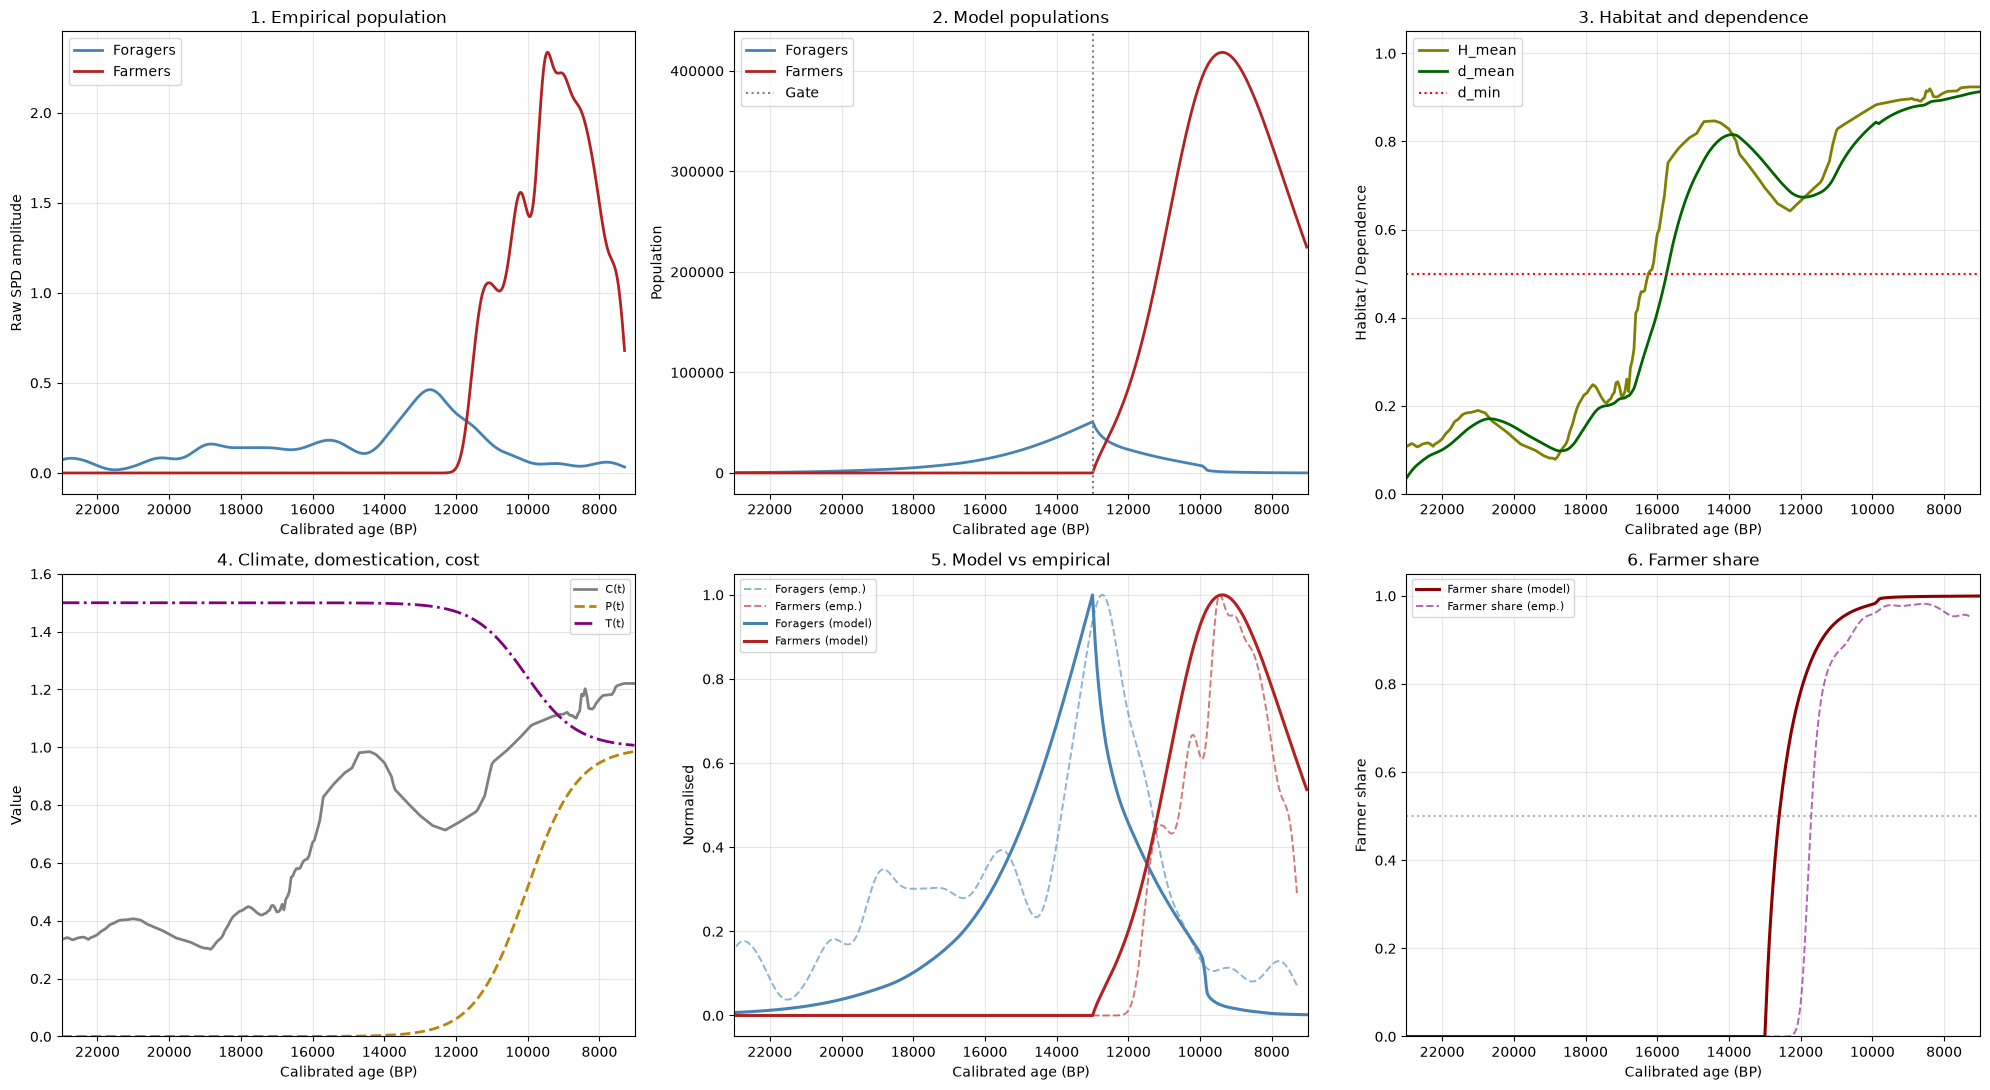

In [9]:
def load_empirical():
    f = np.load(_SPD_DIR /"levant_forager_spd.npz")
    a = np.load(_SPD_DIR /"levant_farmer_spd.npz")
    return {
        "x": f["age"],
        "forager": f["median"],
        "farmer": a["median"],
        "forager_raw": f["raw"] if "raw" in f.files else f["median"],
        "farmer_raw": a["raw"] if "raw" in a.files else a["median"],
    }

emp = load_empirical()
ex = emp["x"]
elm_n = emp["forager_raw"] / emp["forager_raw"].max()
efm_n = emp["farmer_raw"] / emp["farmer_raw"].max()

Fn = F_2003 / F_2003.max()
An = A_2003 / A_2003.max()
C_2003 = np.array([m_2003.climate(ti) for ti in t_2003])

fig, axs = plt.subplots(2, 3, figsize=(20, 11))

ax = axs[0, 0]
ax.plot(ex, emp["forager_raw"], color="steelblue", lw=2,
        label="Foragers")
ax.plot(ex, emp["farmer_raw"], color="firebrick", lw=2,
        label="Farmers")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Raw SPD amplitude")
ax.set_title("1. Empirical population")
ax.grid(alpha=0.3)
ax.legend()

ax = axs[0, 1]
ax.plot(t_2003, F_2003, color="steelblue", lw=2, label="Foragers")
ax.plot(t_2003, A_2003, color="firebrick", lw=2, label="Farmers")
ax.axvline(DOMESTICATION_START_BP, color="grey", ls=":",
           label="Gate")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Population")
ax.set_title("2. Model populations")
ax.grid(alpha=0.3)
ax.legend()

ax = axs[0, 2]
ax.plot(t_2003, H_2003, color="olive", lw=2, label="H_mean")
ax.plot(t_2003, d_2003, color="darkgreen", lw=2, label="d_mean")
ax.axhline(0.5, color="red", ls=":", label="d_min")
ax.set_xlim(T_START, T_END)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Habitat / Dependence")
ax.set_title("3. Habitat and dependence")
ax.grid(alpha=0.3)
ax.legend()

ax = axs[1, 0]
ax.plot(t_2003, C_2003, color="grey", lw=2, label="C(t)")
ax.plot(t_2003, P_2003, color="darkgoldenrod", lw=2,
        ls="--", label="P(t)")
ax.plot(t_2003, T_2003, color="purple", lw=2, ls="-.",
        label="T(t)")
ax.set_xlim(T_START, T_END)
ax.set_ylim(0, 1.6)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Value")
ax.set_title("4. Climate, domestication, cost")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axs[1, 1]
ax.plot(ex, elm_n, "steelblue", lw=1.4, ls="--", alpha=0.6,
        label="Foragers (emp.)")
ax.plot(ex, efm_n, "firebrick", lw=1.4, ls="--", alpha=0.6,
        label="Farmers (emp.)")
ax.plot(t_2003, Fn, "steelblue", lw=2.2, label="Foragers (model)")
ax.plot(t_2003, An, "firebrick", lw=2.2, label="Farmers (model)")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Normalised")
ax.set_title("5. Model vs empirical")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axs[1, 2]
denom = emp["forager_raw"] + emp["farmer_raw"]
share_emp = np.where(denom > 1e-6,
                     emp["farmer_raw"] / denom, np.nan)
ax.plot(t_2003, share_2003, color="darkred", lw=2.2,
        label="Farmer share (model)")
ax.plot(ex, share_emp, color="purple", lw=1.4, ls="--",
        alpha=0.6, label="Farmer share (emp.)")
ax.axhline(0.5, color="grey", ls=":", alpha=0.6)
ax.set_xlim(T_START, T_END)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Farmer share")
ax.set_title("6. Farmer share")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Mechanism diagnostics

Panel 7 separates the two conversion routes. Panel 8 shows the cost
comparison. Panel 9 shows the spatial extent of conversion.

Under 2003 the in-situ conversion spike reaches ~2,400 per step at
12,975 BP. Under 2012 the spike is smaller and the transition is
carried by cultural transmission and the declining T(t).

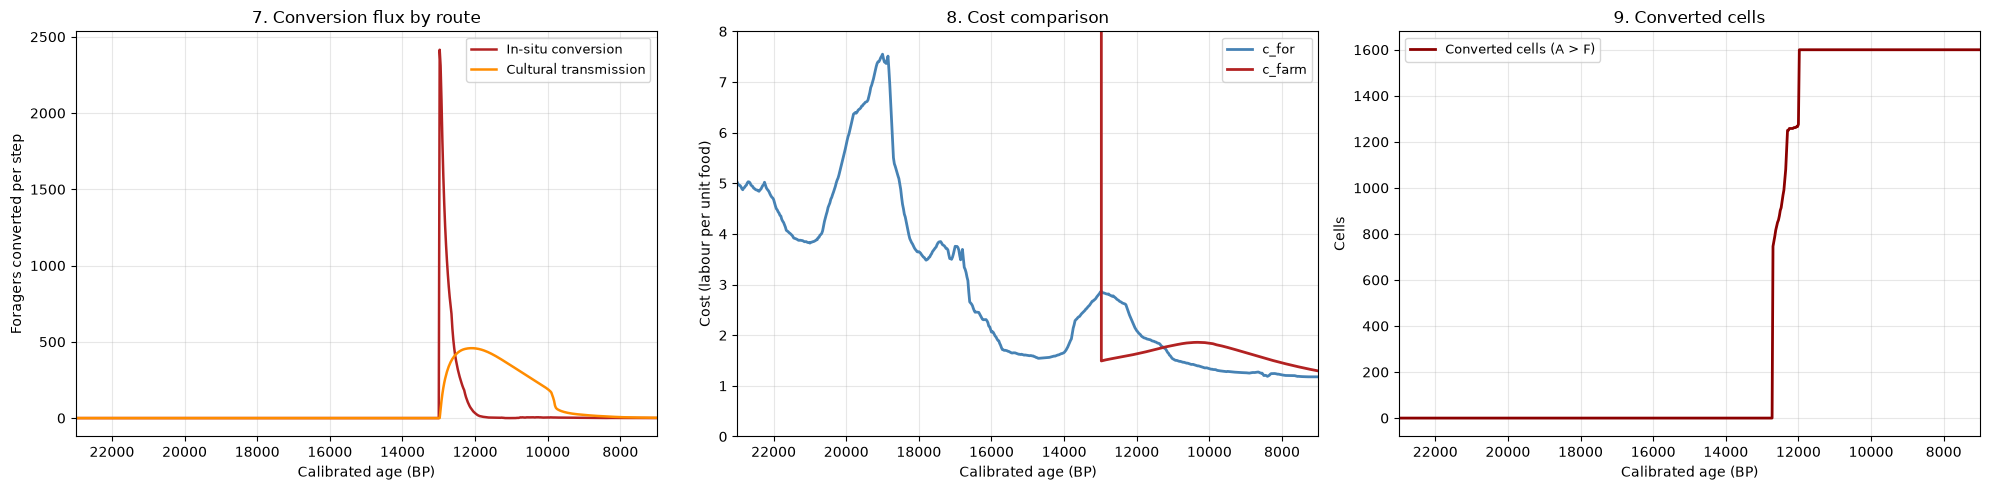

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

ax = axs[0]
ax.plot(t_2003, conv_in_2003, color="firebrick", lw=1.8,
        label="In-situ conversion")
ax.plot(t_2003, conv_cul_2003, color="darkorange", lw=1.8,
        label="Cultural transmission")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Foragers converted per step")
ax.set_title("7. Conversion flux by route")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

ax = axs[1]
ax.plot(t_2003, c_for_2003, "steelblue", lw=2, label="c_for")
ax.plot(t_2003, c_farm_2003, "firebrick", lw=2, label="c_farm")
ax.set_xlim(T_START, T_END)
ax.set_ylim(0, 8)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Cost (labour per unit food)")
ax.set_title("8. Cost comparison")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

ax = axs[2]
ax.plot(t_2003, conv_cells_2003, "darkred", lw=2,
        label="Converted cells (A > F)")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Cells")
ax.set_title("9. Converted cells")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 8. Effects of the calibrated parameter

`SOIL_DEGR` is the only free parameter identified by the fit. Its
value of 0.0004 is the minimum of the MSE surface under the 2003
climate record. The other three free parameters — `TAU_D`,
`K_CONV`, `ALPHA_SHORT` — have flat MSE surfaces across their
plausible ranges and are not identified by the data.

`SOIL_DEGR` controls the shape of the farmer curve through soil
depletion. It does not affect the timing of the transition.

At 0.0004 the farmer curve peaks and declines, matching the
empirical SPD.

The calibration is a trade-off. At 0.0004 versus 0.00015 under the
2003 record, the code cell below prints:

- First conversion age — identical
- Farmer-share crossing year — identical
- Farmer MSE — substantially lower at 0.0004
- Forager MSE — slightly higher at 0.0004
- Share MSE — slightly higher at 0.0004

The calibration improves the farmer fit at the cost of a smaller
degradation of the forager and share fits. Whether the trade-off
is worth making is a modelling choice. It is justified here because
the mechanism's central claim is about the forager decline, which
the calibration does not affect, and because the farmer
peak-and-decline shape that the calibration restores is a
qualitative feature the uncalibrated value cannot produce.

One feature of the table is trivial and should be noted. The
first-conversion age is set by the domestication gate at 13,000 BP
and is the same across all parameter values that do not touch the
gate. Its apparent invariance to `SOIL_DEGR` is a consequence of
the gate. The invariance of the farmer-share crossing year is 
substantive: it says that soil degradation feeds back into the 
shape of the transition.

In [11]:
def evaluate(m, h, emp):
    t = np.array(h["t"])
    F = np.array(h["F"])
    A = np.array(h["A"])
    share = np.array(h["farmer_share"])
    Fn = F / F.max() if F.max() > 0 else F
    An = A / A.max() if A.max() > 0 else A
    elm_n = emp["forager_raw"] / emp["forager_raw"].max()
    efm_n = emp["farmer_raw"] / emp["farmer_raw"].max()
    ex = emp["x"]
    Fn_i = np.interp(ex, t[::-1], Fn[::-1])
    An_i = np.interp(ex, t[::-1], An[::-1])
    mse_f = float(np.mean((Fn_i - elm_n) ** 2))
    mse_a = float(np.mean((An_i - efm_n) ** 2))
    denom = emp["forager_raw"] + emp["farmer_raw"]
    share_emp = np.where(denom > 1e-6,
                         emp["farmer_raw"] / denom, np.nan)
    valid = ~np.isnan(share_emp)
    share_i = np.interp(ex, t[::-1], share[::-1])
    mse_s = float(np.mean(
        (share_i[valid] - share_emp[valid]) ** 2))
    above = np.where(share >= 0.5)[0]
    cross = float(t[above[0]]) if len(above) > 0 else np.nan
    return dict(mse_f=mse_f, mse_a=mse_a,
                mse_total=mse_f + mse_a,
                mse_share=mse_s, cross=cross,
                first_conv=m.first_conversion_bp)

results = {}
for sd in [0.00015, 0.0004]:
    m = Model(seed=42, climate_path=_DATA_DIR /"levant_climate.csv",
              SOIL_DEGR=sd)
    h = m.run(verbose=False)
    results[sd] = evaluate(m, h, emp)

print("SOIL_DEGR comparison (2003 record):")
header = (f"{'SOIL_DEGR':>12s} {'MSE_tot':>10s} "
          f"{'MSE_for':>10s} {'MSE_far':>10s} "
          f"{'MSE_share':>10s} {'cross':>8s} {'first_conv':>12s}")
print(header)
print("-" * len(header))
for sd in [0.00015, 0.0004]:
    r = results[sd]
    print(f"{sd:>12.5f} {r['mse_total']:>10.4f} "
          f"{r['mse_f']:>10.4f} {r['mse_a']:>10.4f} "
          f"{r['mse_share']:>10.4f} {r['cross']:>8.0f} "
          f"{r['first_conv']:>12.0f}")

SOIL_DEGR comparison (2003 record):
   SOIL_DEGR    MSE_tot    MSE_for    MSE_far  MSE_share    cross   first_conv
------------------------------------------------------------------------------
     0.00015     0.0414     0.0269     0.0146     0.0265    12600        12975
     0.00040     0.0360     0.0273     0.0087     0.0265    12600        12975


## 9. Ensemble with climate noise

The model was run 200 times with Ornstein-Uhlenbeck noise on log
C(t) (sigma = 0.005, tau = 2000 yr). Onset is deterministic at
12,975 BP; completion is stochastic with a single preferred window
at ~12,650 BP and a heavy left tail.

Run `python run_grid_ensemble.py 200 levant_climate.csv 0.005`.
The cell below runs a 30-seed version for demonstration.

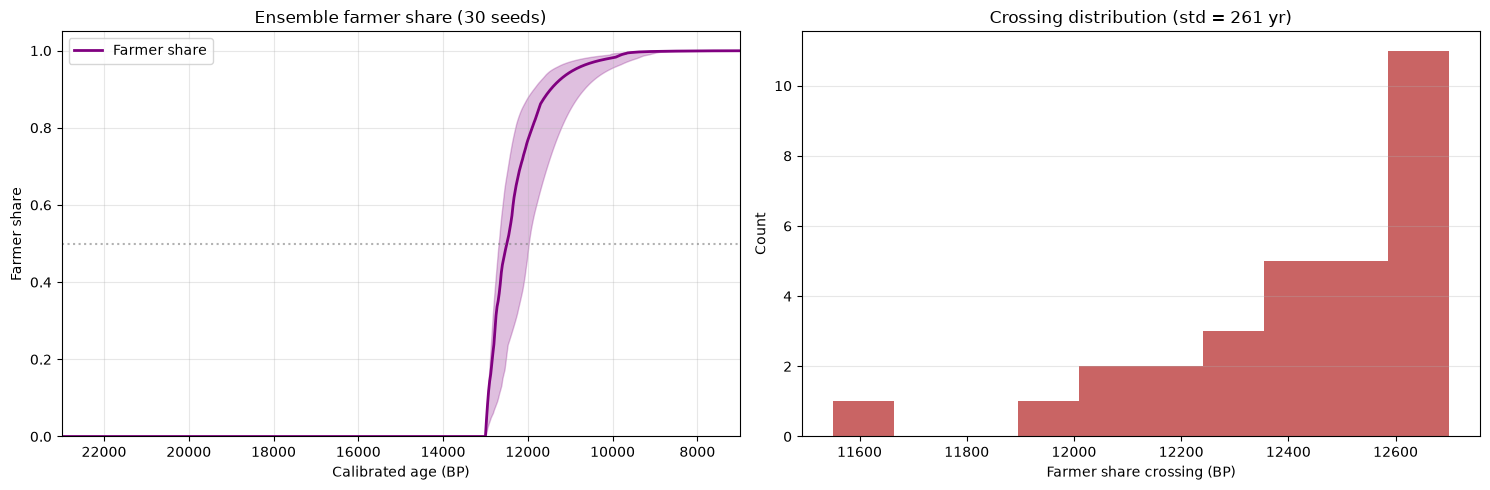

In [ ]:
from latest_levant_model import Model as GridModel

n_seeds = 30
t_ref = None
share_all = []
cross_yr = []
for seed in range(n_seeds):
    m = GridModel(seed=seed, climate_path=_DATA_DIR /"levant_climate.csv",
                  noise_sigma=0.005)
    h = m.run(verbose=False)
    t = np.array(h["t"])
    share = np.array(h["farmer_share"])
    if t_ref is None:
        t_ref = t
    share_all.append(share)
    above = np.where(share >= 0.5)[0]
    cross_yr.append(float(t[above[0]])
                    if len(above) > 0 else np.nan)

share_arr = np.array(share_all)

fig, axs = plt.subplots(1, 2, figsize=(15, 5))

ax = axs[0]
ax.fill_between(t_ref,
                np.percentile(share_arr, 5, axis=0),
                np.percentile(share_arr, 95, axis=0),
                color="purple", alpha=0.25)
ax.plot(t_ref, np.median(share_arr, axis=0), color="purple",
        lw=2, label="Farmer share")
ax.axhline(0.5, color="grey", ls=":", alpha=0.6)
ax.set_xlim(T_START, T_END)
ax.set_ylim(0, 1.05)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Farmer share")
ax.set_title(f"Ensemble farmer share ({n_seeds} seeds)")
ax.grid(alpha=0.3)
ax.legend()

ax = axs[1]
ax.hist(cross_yr, bins=max(5, n_seeds // 3),
        color="firebrick", alpha=0.7)
ax.set_xlabel("Farmer share crossing (BP)")
ax.set_ylabel("Count")
ax.set_title(f"Crossing distribution "
             f"(std = {np.nanstd(cross_yr):.0f} yr)")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 10. Sensitivity sweep

Under the 2003 record `SOIL_DEGR` has a well-located minimum at
0.0004. Under 2012 the minimum is at 0.0006, but that value removes
the interior farmer peak under 2003. The single value of 0.0004 is
used because it preserves the mechanism's qualitative signature
under both records.

Run `python run_sensitivity.py` for the full sweep.

In [ ]:
print("Sensitivity sweep: see figures/sensitivity_levant_climate.png")
print("Regenerate with: python scripts/run_sensitivity.py data/<record>.csv")
print()
print("Summary (2003, Bar-Matthews):")
print("  TAU_D       0.0305-0.0360  cross 12,450-12,600  (flat)")
print("  K_CONV      0.0329-0.0367  cross 12,525-12,600  (flat)")
print("  ALPHA_SHORT 0.0294-0.0484  cross 12,425-12,675  (flat)")
print("  SOIL_DEGR   min at 0.0004  cross 12,600 (const)")
print()
print("Summary (2012, Orland):")
print("  TAU_D       0.0329-0.0359  cross 12,375-12,600  (flat)")
print("  K_CONV      0.0329-0.0337  cross 12,325-12,500  (flat)")
print("  ALPHA_SHORT 0.0331-0.0332  cross 12,475 (const)  (no effect)")
print("  SOIL_DEGR   min at 0.0006  cross 12,475 (const)")
print()
print("Model configuration:")
print("  SOIL_DEGR = 0.0004 for both records.")
print("  0.0004 is the 2003 MSE minimum and preserves the interior")
print("  farmer peak under both records. Under 2012 the MSE minimum")
print("  alone would be 0.0006, but that value removes the interior")
print("  peak under 2003, so 0.0004 is used for both.")

Sensitivity sweep is run by `python run_sensitivity.py`.
See figures/sensitivity_levant_climate.png for output.

Summary (2003):
  TAU_D       0.0363-0.0404  cross 12,450-12,600  (flat)
  K_CONV      0.0381-0.0410  cross 12,525-12,600  (flat)
  ALPHA_SHORT 0.0358-0.0510  cross 12,425-12,675  (flat)
  SOIL_DEGR   min at 0.0004  cross 12,600 (const)

Summary (2012):
  TAU_D       0.0323-0.0349  cross 12,375-12,600  (flat)
  K_CONV      0.0322-0.0329  cross 12,325-12,500  (flat)
  ALPHA_SHORT 0.0324-0.0325  cross 12,475 (const)  (no effect)
  SOIL_DEGR   min at 0.0006  cross 12,475 (const)


## 11. Null comparison

A climate-driven logistic null model was fitted to the same SPD.
Both models run at `SOIL_DEGR = 0.0004`.

**Forager.** Cereal is 4.4x-5.0x better on full MSE. The null's
direction correlation in the YD window is -0.99 (its forager curve
moves opposite to the empirical through the entire YD decline).
The cereal model tracks at +0.89 to +0.90.

**Farmer.** The null wins the rise window because its onset is
fitted. The cereal model wins the peak+decline window by a factor
of two to five, because the null's farmer curve rises monotonically
through a window where the empirical curve declines.

Best null parameters:
  r_F        = 0.0002
  K_F        = 200.0
  r_A        = 0.0002
  K_A        = 100000.0
  A_START    = 11500.0

Null total MSE: 0.1363


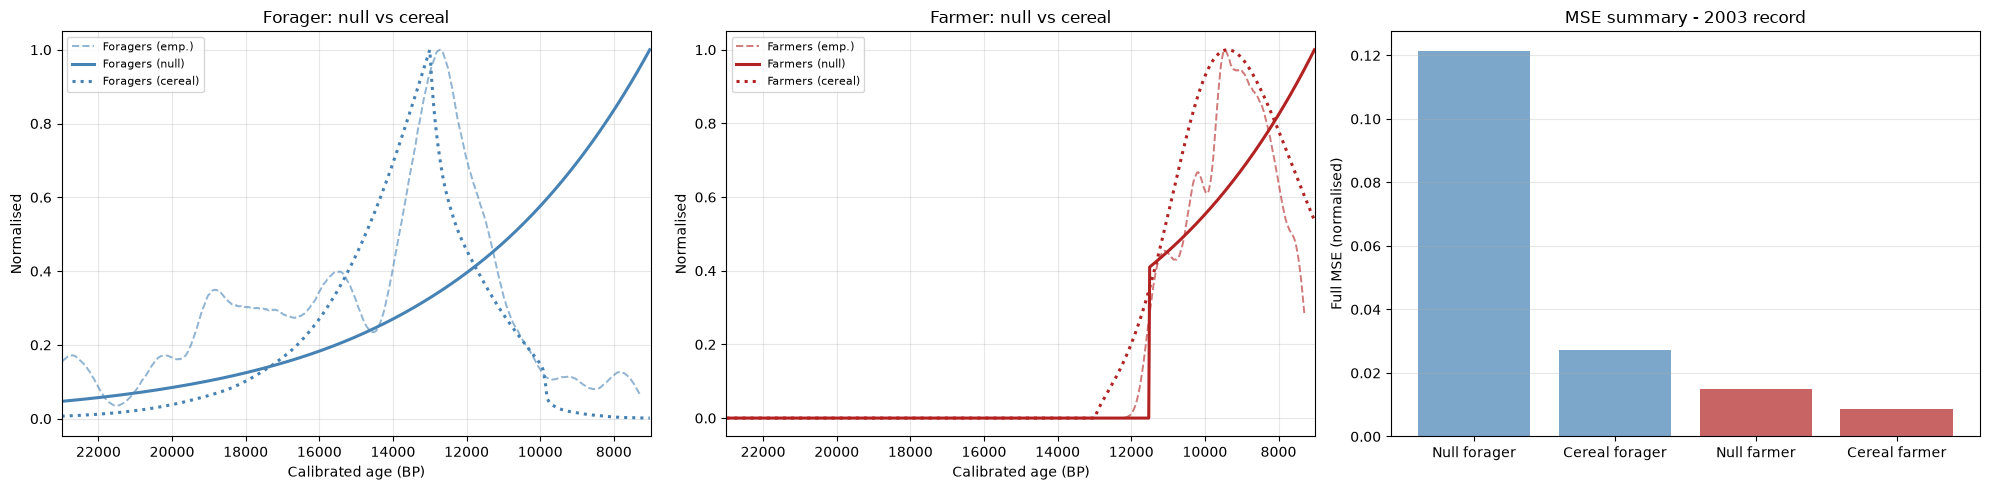

In [ ]:
from levant_null import fit_null_v2

best, (t_null, F_null, A_null) = fit_null_v2(
    emp, climate_path=_DATA_DIR /"levant_climate.csv", verbose=False)

print("Best null parameters:")
for k in ["r_F", "K_F", "r_A", "K_A", "A_START"]:
    print(f"  {k:10s} = {best[k]}")
print(f"\nNull total MSE: {best['mse_total']:.4f}")

Fn_null = F_null / F_null.max()
An_null = A_null / A_null.max()

fig, axs = plt.subplots(1, 3, figsize=(20, 5))

ax = axs[0]
ax.plot(ex, elm_n, "steelblue", lw=1.4, ls="--", alpha=0.6,
        label="Foragers (emp.)")
ax.plot(t_null, Fn_null, "steelblue", lw=2.2,
        label="Foragers (null)")
ax.plot(t_2003, Fn, "steelblue", lw=2.2, ls=":",
        label="Foragers (cereal)")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Normalised")
ax.set_title("Forager: null vs cereal")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axs[1]
ax.plot(ex, efm_n, "firebrick", lw=1.4, ls="--", alpha=0.6,
        label="Farmers (emp.)")
ax.plot(t_null, An_null, "firebrick", lw=2.2,
        label="Farmers (null)")
ax.plot(t_2003, An, "firebrick", lw=2.2, ls=":",
        label="Farmers (cereal)")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Normalised")
ax.set_title("Farmer: null vs cereal")
ax.grid(alpha=0.3)
ax.legend(fontsize=8)

ax = axs[2]
ax.bar(["Null forager", "Cereal forager",
        "Null farmer", "Cereal farmer"],
       [0.1215, 0.0273, 0.0149, 0.0087],
       color=["steelblue", "steelblue", "firebrick", "firebrick"],
       alpha=0.7)
ax.set_ylabel("Full MSE (normalised)")
ax.set_title("MSE summary - 2003 record")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## 12. Gate-removal test

Without the domestication gate, the mechanism fires at ~16,000 BP,
~3,000 years before the archaeologically attested onset. The gate
is what times the onset correctly. The mechanism predicts the
shape and rate of the transition after onset, not the onset itself.

The cell below runs both configurations in memory. To reproduce
the standalone script, run `python run_no_gate.py` once it is in
the repository.

Gated first conversion:   12975 BP
Ungated first conversion: 17150 BP
Difference: -4175 years


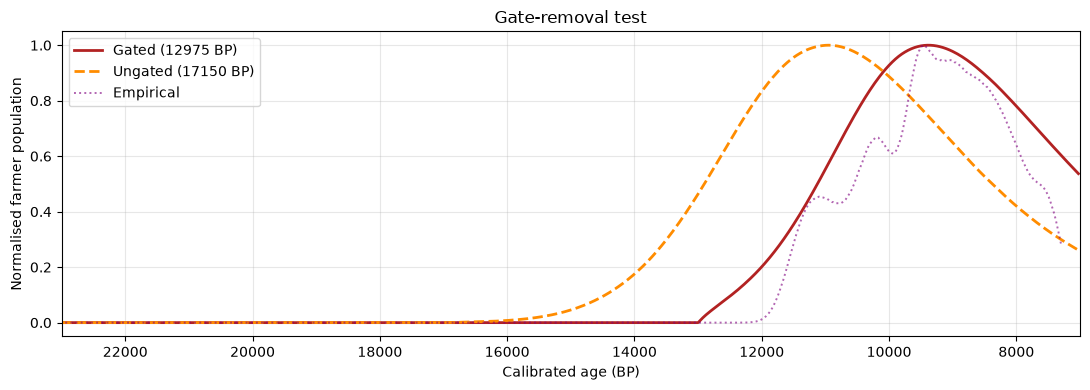

In [ ]:
from latest_levant_model import Model

m_gated = Model(seed=42, climate_path=_DATA_DIR /"levant_climate.csv")
h_gated = m_gated.run(verbose=False)
t_gated = np.array(h_gated["t"])
A_gated = np.array(h_gated["A"])

m_ungated = Model(seed=42, climate_path=_DATA_DIR /"levant_climate.csv",
                  DOMESTICATION_START_BP=T_START)
h_ungated = m_ungated.run(verbose=False)
t_ungated = np.array(h_ungated["t"])
A_ungated = np.array(h_ungated["A"])

gated_onset = m_gated.first_conversion_bp
ungated_onset = m_ungated.first_conversion_bp
print(f"Gated first conversion:   {gated_onset:.0f} BP")
print(f"Ungated first conversion: {ungated_onset:.0f} BP")
if gated_onset and ungated_onset:
    print(f"Difference: {gated_onset - ungated_onset:.0f} years")

A_gated_n = A_gated / A_gated.max()
A_ungated_n = A_ungated / A_ungated.max()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_gated, A_gated_n, "firebrick", lw=2,
        label=f"Gated ({gated_onset:.0f} BP)")
ax.plot(t_ungated, A_ungated_n, "darkorange", lw=2, ls="--",
        label=f"Ungated ({ungated_onset:.0f} BP)")
ax.plot(ex, efm_n, "purple", lw=1.4, ls=":", alpha=0.6,
        label="Empirical")
ax.set_xlim(T_START, T_END)
ax.set_xlabel("Calibrated age (BP)")
ax.set_ylabel("Normalised farmer population")
ax.set_title("Gate-removal test")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 13. Limitations

1. **The onset is a prior.** The gate (13,000 BP) comes from
   archaeology. Without it, the model fires at ~16,000 BP.

2. **SOIL_DEGR is calibrated, not anchored.** Value 0.0004 is the
   MSE minimum under 2003. Under 2012 the minimum is 0.0006, but
   that value removes the interior farmer peak under 2003. The
   Dead Sea erosion record (Lu et al. 2017) is a qualitative
   justification for the soil mechanism, not a quantitative
   anchor for this parameter.

3. **The two Soreq records are not independent.** Same cave, same
   regional signal.

4. **The rise window favors the null by construction.** The null's
   onset is fitted; the cereal model's is approximately archeological.

5. **The farmer peak is early.** ~65 years early under 2003,
   ~715 years early under 2012.

6. **The transition is spatially complete.** All 1,600 cells
   convert by 11,500 BP. The model has no mechanism for refugia
   in the arid margins.

7. **The crossing-time distribution is heavy-tailed.** ~10% of
   realizations complete 400-1,100 years before the mode.

8. **Spatial precipitation is a modern climatology.**

The strongest claim is the forager result: the mechanism produces
the YD-driven forager decline, which no climate-driven logistic
reproduces. It is unaffected by the SOIL_DEGR calibration.

## 14. References

See `README.md` for full citations. Key sources:

- Bar-Matthews et al. (2003) - Soreq Cave climate record.
- Orland et al. (2012) - high-resolution Soreq record.
- Arranz-Otaegui et al. (2016) - domestication timing.
- Bowles (2011) - farming/foraging cost ratio.
- Tanno & Willcox (2006); Fuller et al. (2014, 2016) -
  non-shattering rachis curve.
- Lu et al. (2017) - Dead Sea erosion and Neolithic impact.
- Hartman et al. (2016) - YD cooling in the southern Levant.
- LaPolice, T.M., Williams, M.P., Huber, C.D. (2025) - cultural transmission rate.